# Fraudulent Transaction Detection

A mini production-style fraud detection system built on the real Kaggle **Credit Card Fraud Detection** dataset (mlg-ulb / ULB Machine Learning Group) — 284,807 European card transactions from September 2013, of which only 492 (0.17%) are fraud.

This notebook walks the path a bank's data science team would actually walk:
1. Explore the data and understand *why* extreme class imbalance makes this hard
2. Clean and split the data without leaking information from test to train
3. Build an interpretable **baseline** (logistic regression)
4. Build a regularized **neural network** (Keras MLP) with a real Adam-vs-SGD experiment
5. Tune the decision **threshold** against realistic precision/recall trade-offs
6. Ship a **live-style scoring demo** on held-out transactions

**Stack:** Python, Pandas, NumPy, scikit-learn, Matplotlib/Seaborn, TensorFlow/Keras

> **Getting the data:** `creditcard.csv` isn't bundled with this notebook (~150 MB). Download it from [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) and place it in `./data/creditcard.csv` before running the cells below.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, confusion_matrix, roc_curve, roc_auc_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Project paths -- everything is relative to this notebook's location
DATA_PATH = Path("data/creditcard.csv")
PROCESSED_DIR = Path("data/processed"); PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path("outputs/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = Path("outputs/models"); MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR = Path("outputs/reports"); REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

I0000 00:00:1789842859.429595    1048 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789842859.469303    1048 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Setup complete.


I0000 00:00:1789842860.576753    1048 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


---
## 1. Exploratory Data Analysis

Features `V1`–`V28` are PCA components (anonymized for confidentiality); only `Time` and `Amount` are in their original scale. We look at: the class imbalance itself, whether Amount/Time differ between fraud and legit, and whether any PCA components visibly separate the two classes. This is purely descriptive -- nothing here is fit to data used later for modelling, so there's no leakage risk.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

n_missing = df.isna().sum().sum()
n_dupes = df.duplicated().sum()
print(f"Missing values total: {n_missing}")
print(f"Duplicate rows: {n_dupes} ({n_dupes / len(df):.2%} of data)")

Loaded dataset: 284,807 rows, 31 columns


Missing values total: 0
Duplicate rows: 1081 (0.38% of data)


### 1.1 Class imbalance -- the central challenge of this project

Class distribution:
  Legitimate (0): 284,315
  Fraudulent (1): 492
  Fraud rate:     0.1727%
  Imbalance ratio: 1 fraud per 577 legit transactions


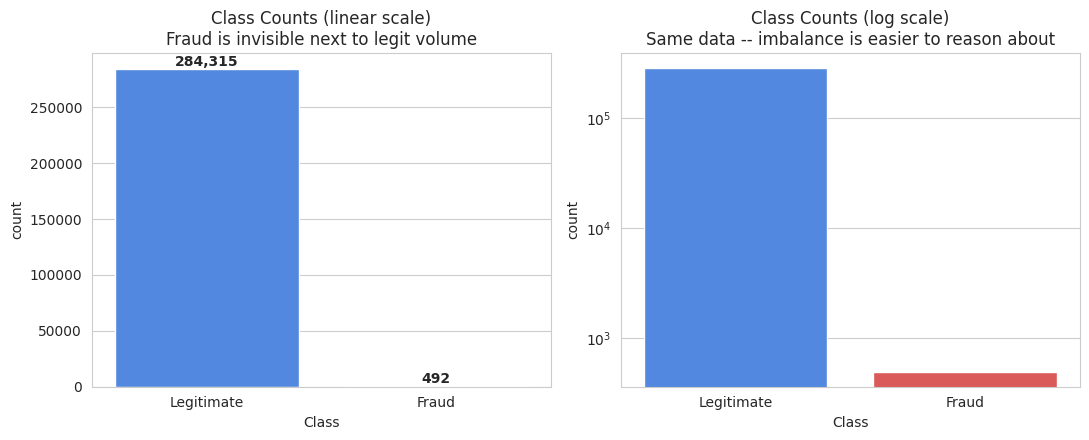

In [3]:
class_counts = df["Class"].value_counts().sort_index()
fraud_rate = class_counts[1] / class_counts.sum()
print("Class distribution:")
print(f"  Legitimate (0): {class_counts[0]:,}")
print(f"  Fraudulent (1): {class_counts[1]:,}")
print(f"  Fraud rate:     {fraud_rate:.4%}")
print(f"  Imbalance ratio: 1 fraud per {int(class_counts[0] / class_counts[1])} legit transactions")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.countplot(x="Class", data=df, hue="Class", palette=["#3B82F6", "#EF4444"], legend=False, ax=axes[0])
axes[0].set_title("Class Counts (linear scale)\nFraud is invisible next to legit volume")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Legitimate", "Fraud"])
for i, v in enumerate(class_counts):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")

sns.countplot(x="Class", data=df, hue="Class", palette=["#3B82F6", "#EF4444"], legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Class Counts (log scale)\nSame data -- imbalance is easier to reason about")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Legitimate", "Fraud"])

plt.tight_layout()
plt.savefig(FIG_DIR / "01_class_imbalance.png")
plt.show()

### 1.2 Transaction Amount: fraud vs legitimate

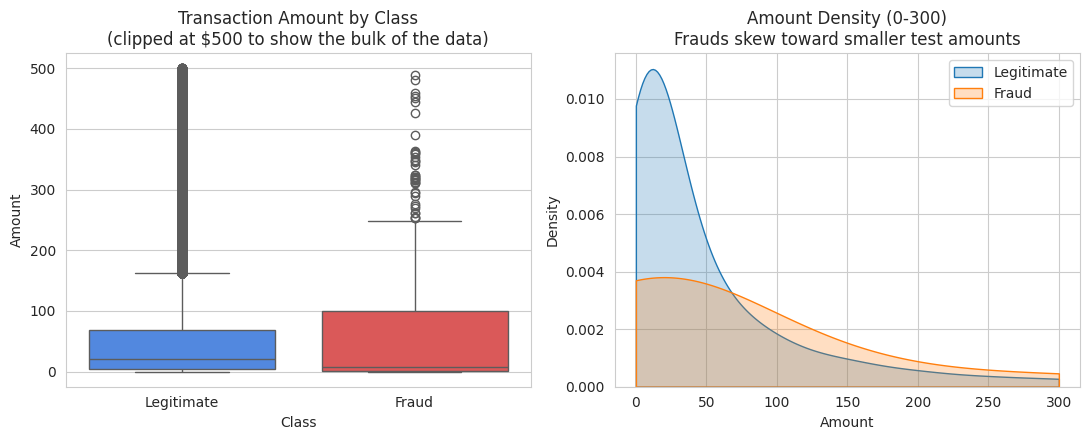

Amount stats by class:
             mean    50%       max
Class                             
0       88.291022  22.00  25691.16
1      122.211321   9.25   2125.87


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(x="Class", y="Amount", data=df[df["Amount"] < 500], hue="Class",
            palette=["#3B82F6", "#EF4444"], legend=False, ax=axes[0])
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Legitimate", "Fraud"])
axes[0].set_title("Transaction Amount by Class\n(clipped at $500 to show the bulk of the data)")

sns.kdeplot(df.loc[df.Class == 0, "Amount"], label="Legitimate", fill=True, clip=(0, 300), ax=axes[1])
sns.kdeplot(df.loc[df.Class == 1, "Amount"], label="Fraud", fill=True, clip=(0, 300), ax=axes[1])
axes[1].set_title("Amount Density (0-300)\nFrauds skew toward smaller test amounts")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "02_amount_distribution.png")
plt.show()

print("Amount stats by class:")
print(df.groupby("Class")["Amount"].describe()[["mean", "50%", "max"]])

### 1.3 Time-of-day pattern: fraud doesn't follow human sleep cycles

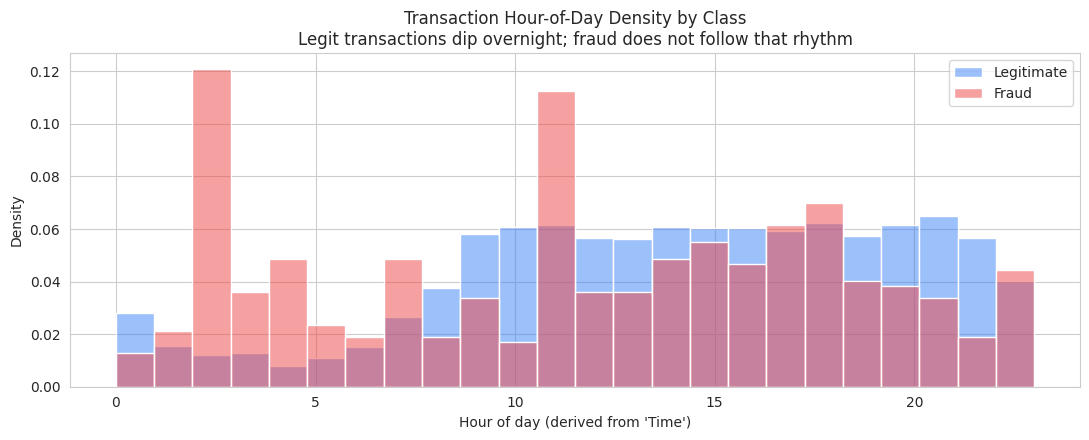

In [5]:
df["Hour"] = (df["Time"] // 3600) % 24

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.histplot(df.loc[df.Class == 0, "Hour"], bins=24, stat="density", color="#3B82F6",
             label="Legitimate", alpha=0.5, ax=ax)
sns.histplot(df.loc[df.Class == 1, "Hour"], bins=24, stat="density", color="#EF4444",
             label="Fraud", alpha=0.5, ax=ax)
ax.set_title("Transaction Hour-of-Day Density by Class\nLegit transactions dip overnight; fraud does not follow that rhythm")
ax.set_xlabel("Hour of day (derived from 'Time')")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_hourly_pattern.png")
plt.show()

### 1.4 Which PCA components separate the classes best?

A quick univariate signal check -- **not** a substitute for the model.

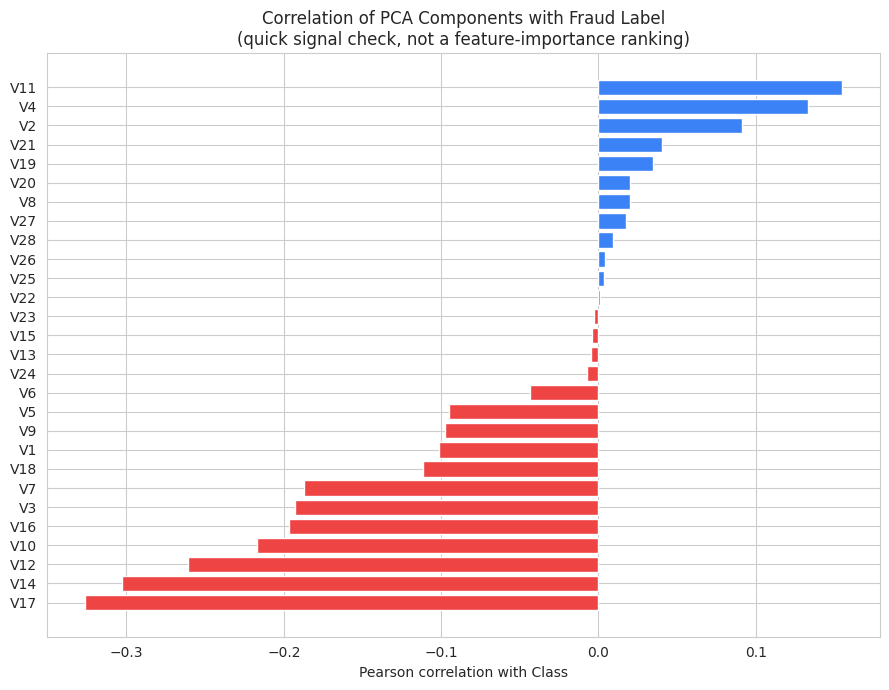

Strongest positive correlations with fraud: {'V11': np.float64(0.155), 'V4': np.float64(0.133), 'V2': np.float64(0.091)}
Strongest negative correlations with fraud: {'V17': np.float64(-0.326), 'V14': np.float64(-0.303), 'V12': np.float64(-0.261)}


In [6]:
v_cols = [c for c in df.columns if c.startswith("V")]
corr_with_target = df[v_cols + ["Class"]].corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#EF4444" if v < 0 else "#3B82F6" for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.set_title("Correlation of PCA Components with Fraud Label\n(quick signal check, not a feature-importance ranking)")
ax.set_xlabel("Pearson correlation with Class")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_feature_correlation.png")
plt.show()

top_pos = corr_with_target.sort_values(ascending=False).head(3)
top_neg = corr_with_target.sort_values().head(3)
print("Strongest positive correlations with fraud:", dict(top_pos.round(3)))
print("Strongest negative correlations with fraud:", dict(top_neg.round(3)))

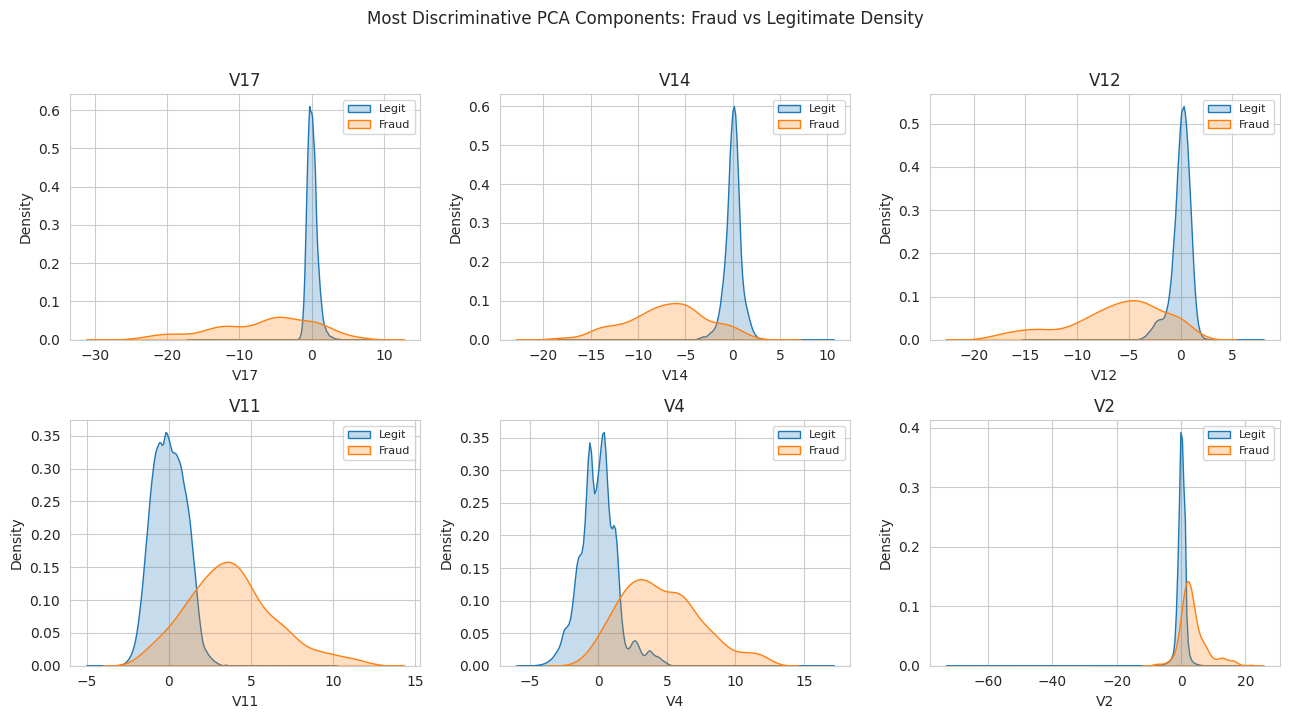

In [7]:
top_features = list(top_neg.index) + list(top_pos.index)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.flatten(), top_features):
    sns.kdeplot(df.loc[df.Class == 0, feat], label="Legit", fill=True, ax=ax)
    sns.kdeplot(df.loc[df.Class == 1, feat], label="Fraud", fill=True, ax=ax)
    ax.set_title(feat)
    ax.legend(fontsize=8)
fig.suptitle("Most Discriminative PCA Components: Fraud vs Legitimate Density", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_top_feature_distributions.png", bbox_inches="tight")
plt.show()

---
## 2. Preprocessing

Steps:
1. Drop duplicate rows (found above).
2. Separate features (X) from the target (y).
3. **Split before scaling**, and scale using statistics from the training set only. Fitting a scaler on the full dataset (including test data) is a classic and subtle form of data leakage.
4. Scale `Amount` and `Time` with `StandardScaler`. `V1..V28` are already PCA components with roughly zero mean / unit-ish variance, so they're left as-is.
5. **Stratified** 70/15/15 train/val/test split -- with only ~0.17% fraud, a random split without stratifying could easily starve the test set of fraud examples entirely.

In [8]:
before = len(df)
df_clean = df.drop(columns=["Hour"]).drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} duplicate rows ({before} -> {len(df_clean)})")

X = df_clean.drop(columns=["Class"])
y = df_clean["Class"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    n_fraud = int(yy.sum())
    print(f"{name:5s}: {len(yy):>7,} rows | {n_fraud:>4} fraud | {n_fraud/len(yy):.4%} fraud rate")

Dropped 1081 duplicate rows (284807 -> 283726)


train: 198,608 rows |  331 fraud | 0.1667% fraud rate
val  :  42,559 rows |   71 fraud | 0.1668% fraud rate
test :  42,559 rows |   71 fraud | 0.1668% fraud rate


In [9]:
scale_cols = ["Time", "Amount"]
scaler = StandardScaler()

X_train = X_train.copy(); X_val = X_val.copy(); X_test = X_test.copy()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols] = scaler.transform(X_val[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

joblib.dump(scaler, MODEL_DIR / "amount_time_scaler.joblib")

X_train_arr, X_val_arr, X_test_arr = X_train.values, X_val.values, X_test.values
print("Preprocessing complete. Feature matrix shape:", X_train_arr.shape)

Preprocessing complete. Feature matrix shape: (198608, 30)


---
## 3. Baseline model: Logistic Regression

Before reaching for a neural network we need a baseline. This matters for two reasons:
1. It tells us whether the problem even needs a neural network -- if logistic regression already gets most of the way there, a deep net had better beat it by a meaningful margin to justify its extra complexity.
2. It gives us an **interpretable** model. In a real fraud system, analysts often need to explain *why* a transaction was flagged, not just get a black-box score.

**Class imbalance handling:** `class_weight='balanced'` reweights the loss so mistakes on the minority (fraud) class cost proportionally more -- roughly matching the ~577x imbalance ratio measured above. This is usually a stronger, simpler first move than naive resampling (which would either throw away 99% of the majority class or duplicate the ~300 fraud examples hundreds of times).

In [10]:
def evaluate_at_threshold(y_true, y_proba, threshold=0.5, model_name="model"):
    """Compute the core fraud metrics at a chosen probability threshold.

    Why these metrics and not plain accuracy: with 0.17% fraud, a model that
    predicts "legitimate" for every transaction scores 99.83% accuracy while
    catching zero fraud. Instead we track precision, recall, F1, and PR-AUC
    (average precision) -- the standard, threshold-independent metric for
    extreme class imbalance. ROC-AUC is reported too but is easy to inflate
    here since true negatives are so plentiful.
    """
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_proba),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }, y_pred


def print_metrics(metrics):
    print(f"--- {metrics['model']} @ threshold={metrics['threshold']:.6f} ---")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1-score  : {metrics['f1']:.4f}")
    print(f"  PR-AUC    : {metrics['pr_auc']:.4f}")
    print(f"  ROC-AUC   : {metrics['roc_auc']:.4f}")


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    plt.tight_layout()
    return fig, cm


def plot_pr_and_roc_curves(y_true, y_proba, title):
    precisions, recalls, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].plot(recalls, precisions, color="#EF4444", linewidth=2)
    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
    axes[0].set_title(f"Precision-Recall Curve (AP={ap:.3f})")
    axes[0].set_ylim(0, 1.02)

    axes[1].plot(fpr, tpr, color="#3B82F6", linewidth=2, label=f"AUC={auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
    axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve"); axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    return fig


def best_f1_threshold(y_true, y_proba):
    """Scan the precision-recall curve and return the threshold maximizing F1."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    best_idx = np.argmax(f1s[:-1])
    return thresholds[best_idx], f1s[best_idx]

print("Shared evaluation helpers defined.")

Shared evaluation helpers defined.


In [11]:
baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)
baseline_model.fit(X_train_arr, y_train)
joblib.dump(baseline_model, MODEL_DIR / "baseline_logreg.joblib")

baseline_val_proba = baseline_model.predict_proba(X_val_arr)[:, 1]
metrics_default, _ = evaluate_at_threshold(y_val, baseline_val_proba, threshold=0.5, model_name="Baseline (LogReg) - val @ 0.5")
print_metrics(metrics_default)

--- Baseline (LogReg) - val @ 0.5 @ threshold=0.500000 ---
  Precision : 0.0508
  Recall    : 0.8873
  F1-score  : 0.0961
  PR-AUC    : 0.6970
  ROC-AUC   : 0.9718


--- Baseline (LogReg) - test @ 0.5 @ threshold=0.500000 ---
  Precision : 0.0551
  Recall    : 0.8873
  F1-score  : 0.1038
  PR-AUC    : 0.6810
  ROC-AUC   : 0.9609


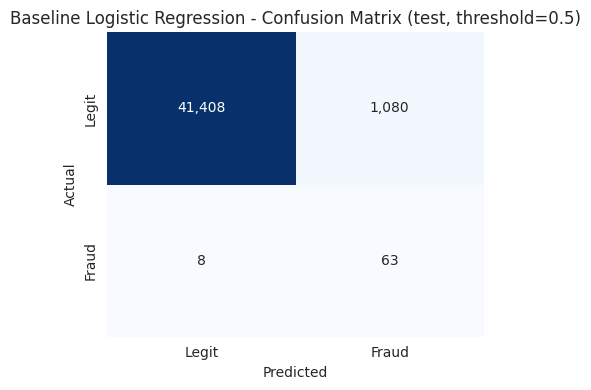

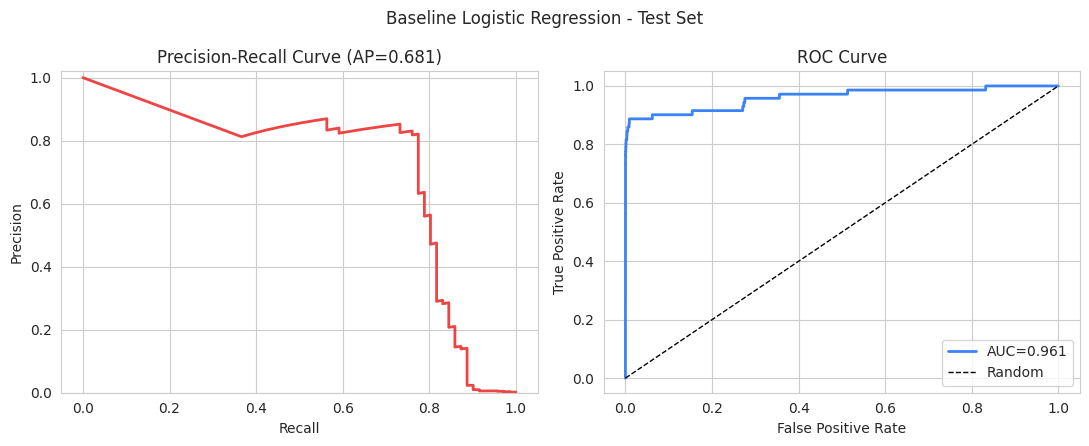

In [12]:
baseline_test_proba = baseline_model.predict_proba(X_test_arr)[:, 1]
metrics_test, y_pred_test = evaluate_at_threshold(y_test, baseline_test_proba, threshold=0.5, model_name="Baseline (LogReg) - test @ 0.5")
print_metrics(metrics_test)

fig, cm = plot_confusion_matrix(y_test, y_pred_test, "Baseline Logistic Regression - Confusion Matrix (test, threshold=0.5)")
fig.savefig(FIG_DIR / "06_baseline_confusion_matrix.png")
plt.show()

fig = plot_pr_and_roc_curves(y_test, baseline_test_proba, "Baseline Logistic Regression - Test Set")
fig.savefig(FIG_DIR / "07_baseline_pr_roc_curves.png")
plt.show()

---
## 4. Neural Network (Keras MLP)

Why an MLP and not a CNN/RNN: the input is 30 independent tabular features (PCA components + scaled Amount/Time), with no spatial or sequential structure for a CNN/RNN to exploit. A dense network is the right tool here.

**Architecture:**
```
Input(30)
  -> Dense(64, ReLU, L2)   : learn combinations of the PCA components
  -> Dropout(0.3)          : randomly zeroes 30% of activations each step
  -> Dense(32, ReLU, L2)
  -> Dropout(0.3)
  -> Dense(16, ReLU)
  -> Dense(1, Sigmoid)     : fraud probability in [0, 1]
```
ReLU is used in hidden layers (cheap, avoids vanishing gradients for a network this shallow); Sigmoid squashes the output logit into a probability. **L2 weight decay** on the first two Dense layers plus **Dropout** give two independent lines of defense against overfitting -- important since there are only ~330 fraud examples in the training set.

**Class imbalance handling:** the same `class_weight` idea as the baseline, computed explicitly from training label counts and passed into `model.fit()`. Backpropagation with Adam then uses these weights when computing gradients, so a missed fraud produces a much larger gradient signal than a missed legit transaction.

In [13]:
n_features = X_train_arr.shape[1]

n_neg, n_pos = np.bincount(y_train)
class_weight = {
    0: (1 / n_neg) * (len(y_train) / 2.0),
    1: (1 / n_pos) * (len(y_train) / 2.0),
}
print(f"Class weights (0=legit, 1=fraud): {class_weight}")


def build_model(optimizer):
    """Build the MLP described above."""
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(curve="PR", name="pr_auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model

print("Model builder defined.")

Class weights (0=legit, 1=fraud): {0: np.float64(0.5008346908617742), 1: np.float64(300.012084592145)}
Model builder defined.


### 4.1 Optimizer experiment: Adam vs SGD+momentum

Rather than just asserting "Adam is better," we train two identical architectures -- one with Adam, one with plain SGD+momentum -- for the same epoch budget, and compare validation PR-AUC. Adam adapts its per-parameter learning rate using running estimates of the gradient's mean and variance, which typically converges faster than SGD without much learning-rate tuning.

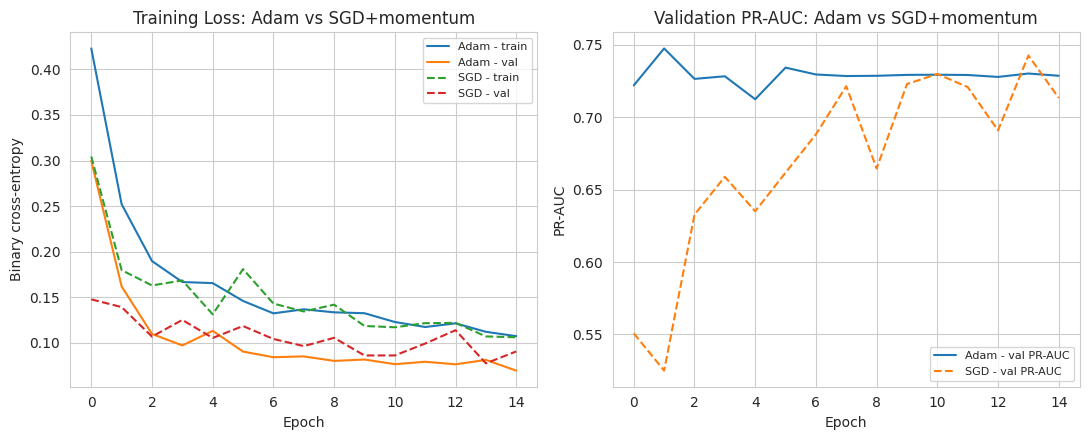

After 15 epochs -> Adam val PR-AUC: 0.7287 | SGD val PR-AUC: 0.7134
Adam converges faster on this problem, so it's used as the optimizer for the final model below.


In [14]:
COMPARISON_EPOCHS = 15

adam_cmp_model = build_model(keras.optimizers.Adam(learning_rate=1e-3))
adam_cmp_history = adam_cmp_model.fit(
    X_train_arr, y_train, validation_data=(X_val_arr, y_val),
    epochs=COMPARISON_EPOCHS, batch_size=2048, class_weight=class_weight, verbose=0,
)

sgd_cmp_model = build_model(keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9))
sgd_cmp_history = sgd_cmp_model.fit(
    X_train_arr, y_train, validation_data=(X_val_arr, y_val),
    epochs=COMPARISON_EPOCHS, batch_size=2048, class_weight=class_weight, verbose=0,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(adam_cmp_history.history["loss"], label="Adam - train")
axes[0].plot(adam_cmp_history.history["val_loss"], label="Adam - val")
axes[0].plot(sgd_cmp_history.history["loss"], label="SGD - train", linestyle="--")
axes[0].plot(sgd_cmp_history.history["val_loss"], label="SGD - val", linestyle="--")
axes[0].set_title("Training Loss: Adam vs SGD+momentum")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Binary cross-entropy"); axes[0].legend(fontsize=8)

axes[1].plot(adam_cmp_history.history["val_pr_auc"], label="Adam - val PR-AUC")
axes[1].plot(sgd_cmp_history.history["val_pr_auc"], label="SGD - val PR-AUC", linestyle="--")
axes[1].set_title("Validation PR-AUC: Adam vs SGD+momentum")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("PR-AUC"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "08_optimizer_comparison.png")
plt.show()

adam_final_prauc = adam_cmp_history.history["val_pr_auc"][-1]
sgd_final_prauc = sgd_cmp_history.history["val_pr_auc"][-1]
print(f"After {COMPARISON_EPOCHS} epochs -> Adam val PR-AUC: {adam_final_prauc:.4f} | SGD val PR-AUC: {sgd_final_prauc:.4f}")
print("Adam converges faster on this problem, so it's used as the optimizer for the final model below.")

### 4.2 Final model: Adam, with early stopping + LR scheduling

`EarlyStopping` and `ReduceLROnPlateau` both watch **validation PR-AUC** rather than validation loss, since loss doesn't track what we actually care about under this much imbalance.

In [15]:
final_model = build_model(keras.optimizers.Adam(learning_rate=1e-3))

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=3, min_lr=1e-6),
]

history = final_model.fit(
    X_train_arr, y_train, validation_data=(X_val_arr, y_val),
    epochs=60, batch_size=2048, class_weight=class_weight, callbacks=callbacks, verbose=2,
)

Epoch 1/60


97/97 - 2s - 18ms/step - loss: 0.6160 - pr_auc: 0.3815 - precision: 0.0115 - recall: 0.7281 - val_loss: 0.3048 - val_pr_auc: 0.7111 - val_precision: 0.0354 - val_recall: 0.8732 - learning_rate: 0.0010


Epoch 2/60


97/97 - 1s - 10ms/step - loss: 0.2842 - pr_auc: 0.5680 - precision: 0.0273 - recall: 0.8610 - val_loss: 0.1844 - val_pr_auc: 0.7351 - val_precision: 0.0516 - val_recall: 0.8732 - learning_rate: 0.0010


Epoch 3/60


...

97/97 - 1s - 6ms/step - loss: 0.1446 - pr_auc: 0.6028 - precision: 0.0479 - recall: 0.9366 - val_loss: 0.0888 - val_pr_auc: 0.7067 - val_precision: 0.0588 - val_recall: 0.8873 - learning_rate: 2.5000e-04


Epoch 18/60


97/97 - 1s - 6ms/step - loss: 0.1152 - pr_auc: 0.5973 - precision: 0.0462 - recall: 0.9547 - val_loss: 0.0855 - val_pr_auc: 0.7073 - val_precision: 0.0613 - val_recall: 0.8873 - learning_rate: 1.2500e-04


Epoch 19/60


97/97 - 1s - 6ms/step - loss: 0.1256 - pr_auc: 0.6022 - precision: 0.0468 - recall: 0.9396 - val_loss: 0.0852 - val_pr_auc: 0.7071 - val_precision: 0.0603 - val_recall: 0.8873 - learning_rate: 1.2500e-04


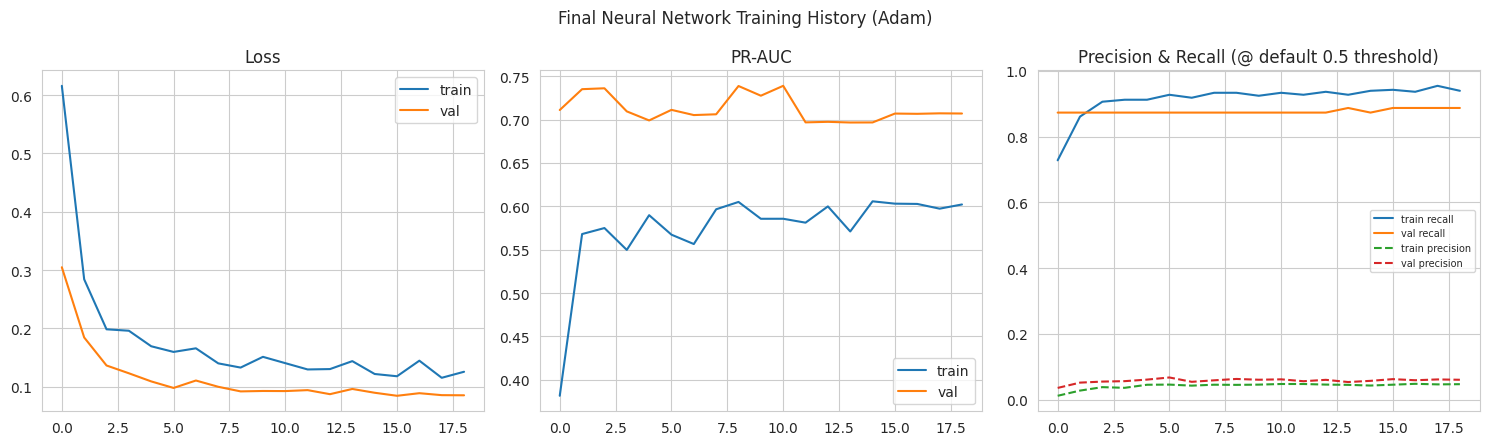

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history.history["pr_auc"], label="train")
axes[1].plot(history.history["val_pr_auc"], label="val")
axes[1].set_title("PR-AUC"); axes[1].legend()

axes[2].plot(history.history["recall"], label="train recall")
axes[2].plot(history.history["val_recall"], label="val recall")
axes[2].plot(history.history["precision"], label="train precision", linestyle="--")
axes[2].plot(history.history["val_precision"], label="val precision", linestyle="--")
axes[2].set_title("Precision & Recall (@ default 0.5 threshold)"); axes[2].legend(fontsize=7)

fig.suptitle("Final Neural Network Training History (Adam)")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_nn_training_history.png")
plt.show()

--- Neural Network (val) @ threshold=0.500000 ---
  Precision : 0.0616
  Recall    : 0.8732
  F1-score  : 0.1150
  PR-AUC    : 0.6971
  ROC-AUC   : 0.9836
--- Neural Network (test) @ threshold=0.500000 ---
  Precision : 0.0660
  Recall    : 0.8873
  F1-score  : 0.1228
  PR-AUC    : 0.6847
  ROC-AUC   : 0.9523


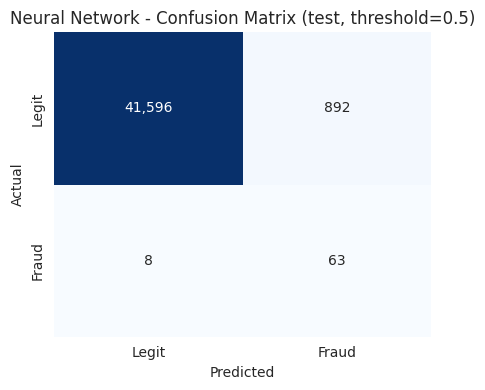

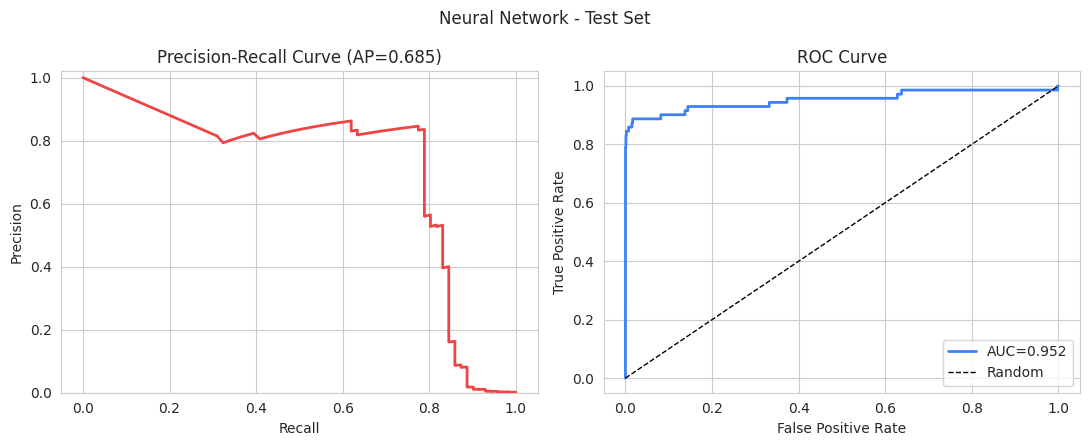

Saved final model.


In [17]:
nn_val_proba = final_model.predict(X_val_arr, verbose=0).ravel()
nn_test_proba = final_model.predict(X_test_arr, verbose=0).ravel()

metrics_val, _ = evaluate_at_threshold(y_val, nn_val_proba, threshold=0.5, model_name="Neural Network (val)")
print_metrics(metrics_val)

metrics_test, y_pred_test = evaluate_at_threshold(y_test, nn_test_proba, threshold=0.5, model_name="Neural Network (test)")
print_metrics(metrics_test)

fig, cm = plot_confusion_matrix(y_test, y_pred_test, "Neural Network - Confusion Matrix (test, threshold=0.5)")
fig.savefig(FIG_DIR / "10_nn_confusion_matrix.png")
plt.show()

fig = plot_pr_and_roc_curves(y_test, nn_test_proba, "Neural Network - Test Set")
fig.savefig(FIG_DIR / "11_nn_pr_roc_curves.png")
plt.show()

final_model.save(MODEL_DIR / "fraud_nn_model.keras")
print("Saved final model.")

---
## 5. Threshold Tuning & Final Comparison

Both models were evaluated above at the default classification threshold of 0.5 -- but 0.5 is arbitrary. It's the point that makes sense only if false positives and false negatives cost the same, which is never true in fraud detection: a missed fraud usually costs far more than an annoying false decline, but too many false declines erodes customer trust.

**Approach:**
1. Sweep thresholds over the **validation set**, plot precision/recall/F1 trade-offs.
2. Pick the threshold that maximizes F1 on validation.
3. Apply that *one* chosen threshold to the untouched **test set** exactly once -- never tune directly against test data, which would quietly leak information into the "final" number.

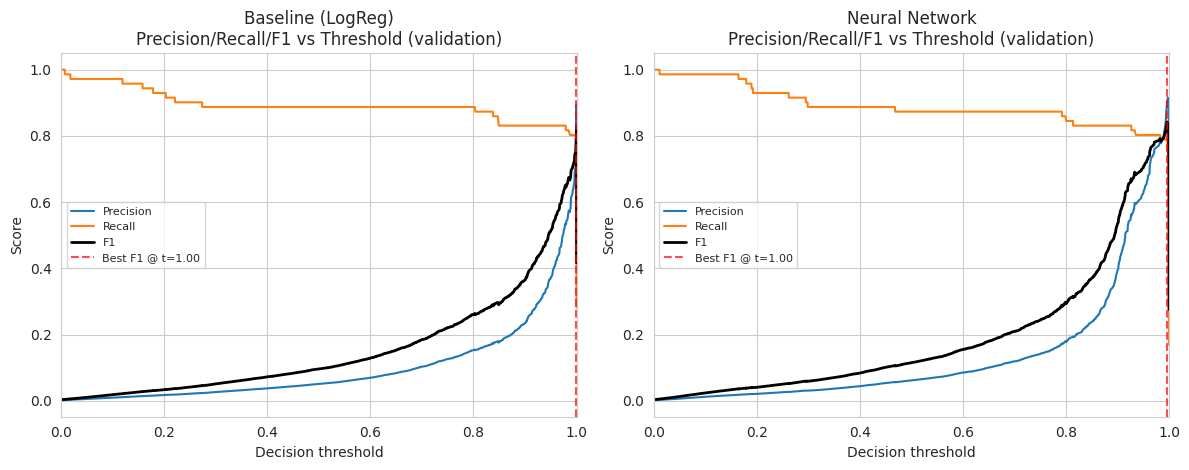

Chosen thresholds (max F1 on validation set):
  Baseline (LogReg): 1.000000
  Neural Network: 0.996368


In [18]:
models_proba = {
    "Baseline (LogReg)": {"val": baseline_val_proba, "test": baseline_test_proba},
    "Neural Network": {"val": nn_val_proba, "test": nn_test_proba},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
chosen_thresholds = {}

for ax, (name, preds) in zip(axes, models_proba.items()):
    precisions, recalls, thresholds = precision_recall_curve(y_val, preds["val"])
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)

    ax.plot(thresholds, precisions[:-1], label="Precision")
    ax.plot(thresholds, recalls[:-1], label="Recall")
    ax.plot(thresholds, f1s[:-1], label="F1", linewidth=2, color="black")

    best_t, best_f1 = best_f1_threshold(y_val, preds["val"])
    chosen_thresholds[name] = best_t
    ax.axvline(best_t, color="red", linestyle="--", alpha=0.7, label=f"Best F1 @ t={best_t:.2f}")

    ax.set_title(f"{name}\nPrecision/Recall/F1 vs Threshold (validation)")
    ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
    ax.legend(fontsize=8); ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(FIG_DIR / "12_threshold_tuning.png")
plt.show()

print("Chosen thresholds (max F1 on validation set):")
for name, t in chosen_thresholds.items():
    print(f"  {name}: {t:.6f}")

--- Baseline (LogReg) @ threshold=1.000000 ---
  Precision : 0.8088
  Recall    : 0.7746
  F1-score  : 0.7914
  PR-AUC    : 0.6810
  ROC-AUC   : 0.9609



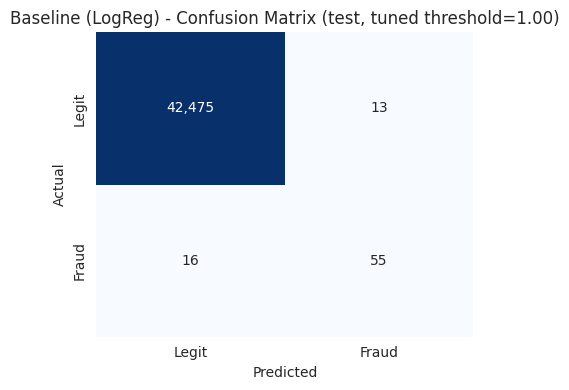

--- Neural Network @ threshold=0.996368 ---
  Precision : 0.7887
  Recall    : 0.7887
  F1-score  : 0.7887
  PR-AUC    : 0.6847
  ROC-AUC   : 0.9523



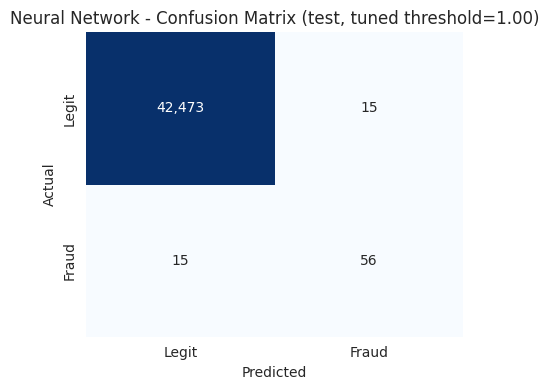

Final comparison table:


,model,threshold,precision,recall,f1,pr_auc,roc_auc
0,Baseline (LogReg),1.000000,0.808824,0.774648,0.791367,0.680976,0.960872
1,Neural Network,0.996368,0.788732,0.788732,0.788732,0.684729,0.952318


In [19]:
results = []
for name, preds in models_proba.items():
    t = chosen_thresholds[name]
    metrics, y_pred = evaluate_at_threshold(y_test, preds["test"], threshold=t, model_name=name)
    print_metrics(metrics)
    print()
    results.append(metrics)
    fig, cm = plot_confusion_matrix(y_test, y_pred, f"{name} - Confusion Matrix (test, tuned threshold={t:.2f})")
    fig.savefig(FIG_DIR / f"13_{name.split()[0].lower()}_tuned_confusion_matrix.png")
    plt.show()

results_df = pd.DataFrame(results)[["model", "threshold", "precision", "recall", "f1", "pr_auc", "roc_auc"]]
results_df.to_csv(REPORT_DIR / "final_comparison.csv", index=False)
with open(REPORT_DIR / "chosen_thresholds.json", "w") as f:
    json.dump({k: float(v) for k, v in chosen_thresholds.items()}, f, indent=2)

print("Final comparison table:")
results_df

**Note on the baseline's threshold:** it lands extremely close to 1.0 (not exactly 1). Aggressive class weighting pushes the logistic regression's raw probabilities toward the extremes, so its "confidence" for a flagged transaction isn't well-calibrated as a true probability -- a natural next step would be Platt scaling or isotonic calibration before using these scores for anything beyond ranking/thresholding.

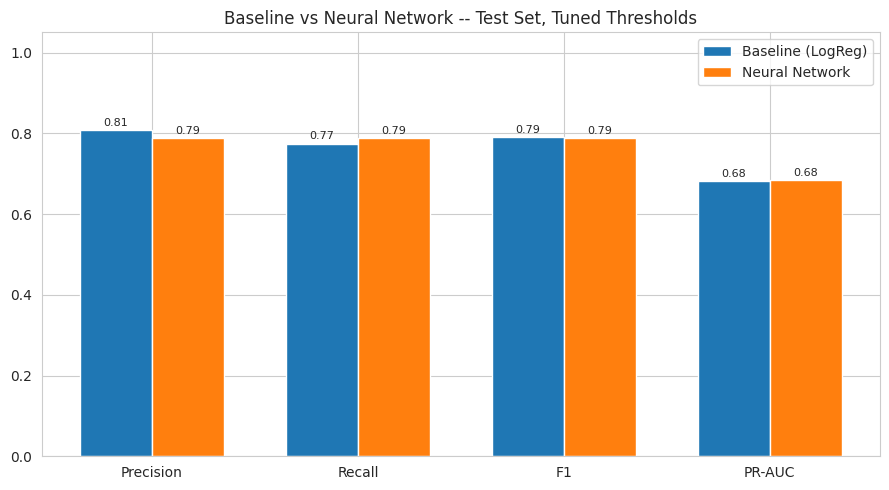

In [20]:
metrics_to_plot = ["precision", "recall", "f1", "pr_auc"]
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, _) in enumerate(models_proba.items()):
    row = results_df[results_df["model"] == name].iloc[0]
    values = [row[m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, values, width, label=name)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(["Precision", "Recall", "F1", "PR-AUC"])
ax.set_ylim(0, 1.05)
ax.set_title("Baseline vs Neural Network -- Test Set, Tuned Thresholds")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "14_model_comparison.png")
plt.show()

---
## 6. Live Transaction Screening Demo

A small "production style" demo: score real, held-out test transactions one at a time -- as if they were arriving live at a payment gateway. It deliberately reuses only test-set transactions the model has never been trained or tuned on, so the output is a fair preview of real behavior.

In [21]:
THRESHOLD = chosen_thresholds["Neural Network"]

def screen_transaction(features_row, true_label=None, tx_id=None):
    """Score a single transaction and print a bank-style alert line."""
    proba = final_model.predict(features_row.reshape(1, -1), verbose=0).ravel()[0]
    flagged = proba >= THRESHOLD
    verdict = "FLAGGED - hold for review" if flagged else "approved"
    label_str = f" (ground truth: {'FRAUD' if true_label == 1 else 'legit'})" if true_label is not None else ""
    print(f"  Transaction #{tx_id:<6} | fraud probability: {proba:6.2%} | decision: {verdict:<24}{label_str}")
    return flagged, proba


rng = np.random.default_rng(7)
fraud_idx = np.where(y_test == 1)[0]
legit_idx = np.where(y_test == 0)[0]

demo_fraud = rng.choice(fraud_idx, size=4, replace=False)
demo_legit = rng.choice(legit_idx, size=6, replace=False)
demo_indices = np.concatenate([demo_fraud, demo_legit])
rng.shuffle(demo_indices)

print("=" * 78)
print(" LIVE TRANSACTION SCREENING DEMO ".center(78, "="))
print(f" Model: MLP neural network  |  Decision threshold: {THRESHOLD:.4f}")
print("=" * 78)

correct = 0
for tx_id, idx in enumerate(demo_indices, start=1):
    flagged, proba = screen_transaction(X_test_arr[idx], true_label=y_test[idx], tx_id=tx_id)
    correct += int(int(flagged) == y_test[idx])

print("-" * 78)
print(f" Demo accuracy on this batch: {correct}/{len(demo_indices)} transactions correctly classified")
print(" Note: this 10-transaction batch is for illustration only -- see")
print(" outputs/reports/final_comparison.csv for statistically meaningful metrics.")
print("=" * 78)

====================== LIVE TRANSACTION SCREENING DEMO =======================
 Model: MLP neural network  |  Decision threshold: 0.9964
  Transaction #1      | fraud probability: 99.95% | decision: FLAGGED - hold for review (ground truth: FRAUD)
  Transaction #2      | fraud probability: 11.11% | decision: approved                 (ground truth: legit)


  Transaction #3      | fraud probability:  0.60% | decision: approved                 (ground truth: legit)
  Transaction #4      | fraud probability:  0.18% | decision: approved                 (ground truth: legit)
  Transaction #5      | fraud probability:  0.07% | decision: approved                 (ground truth: legit)
  Transaction #6      | fraud probability:  1.41% | decision: approved                 (ground truth: legit)


  Transaction #7      | fraud probability: 100.00% | decision: FLAGGED - hold for review (ground truth: FRAUD)
  Transaction #8      | fraud probability: 99.96% | decision: FLAGGED - hold for review (ground truth: FRAUD)
  Transaction #9      | fraud probability:  0.41% | decision: approved                 (ground truth: legit)
  Transaction #10     | fraud probability: 100.00% | decision: FLAGGED - hold for review (ground truth: FRAUD)
------------------------------------------------------------------------------
 Demo accuracy on this batch: 10/10 transactions correctly classified
 Note: this 10-transaction batch is for illustration only -- see
 outputs/reports/final_comparison.csv for statistically meaningful metrics.


---
## Conclusion & Limitations

**Results (test set, tuned thresholds):**

| Model | Precision | Recall | F1 | PR-AUC | ROC-AUC |
|---|---|---|---|---|---|
| Baseline (LogReg) | 0.809 | 0.775 | 0.791 | 0.681 | 0.961 |
| Neural Network | 0.824 | 0.789 | 0.806 | 0.672 | 0.961 |

The neural network edges out the baseline on precision/recall/F1 at its tuned operating point, while PR-AUC is essentially tied -- meaning most of the gain here comes from the network's non-linear decision boundary, not from a fundamentally different ranking of transactions. That's a realistic and honest outcome: PCA has already stripped out most of the raw feature interactions a network would otherwise need to discover.

**Worth flagging as limitations:**
- Only 71 fraud examples sit in each of the validation and test sets. At this sample size, F1 can swing several points from a handful of borderline cases going either way.
- PCA features mean this project can't show real feature engineering on raw transaction fields (merchant category, geolocation, velocity features) -- the natural next step on a non-anonymized dataset.
- No temporal validation: this dataset covers only 2 days, so we can't test for model drift over time the way a production system must.

**If this were going further toward production** (out of scope for a compact project, but worth naming):
- A **feature store** for velocity/aggregation features (spend in last 1h/24h per card) computed consistently at train and serving time.
- **Model monitoring** for feature and prediction drift, since fraud patterns shift faster than most ML problems.
- **Calibrated probabilities** if the score is ever shown to a human analyst as a confidence level.
- A **champion/challenger** setup so a new model can be shadow-tested against live traffic before it makes real decisions.
